## Implementation

In [ ]:
from jaxcmr.helpers import latin_hypercube_sampling

## Tests

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


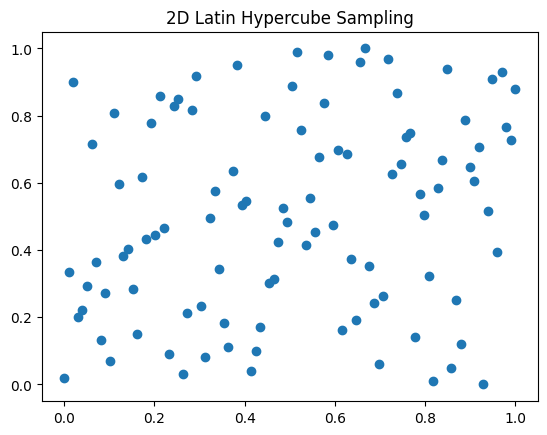

In [2]:
import matplotlib.pyplot as plt
from jax import random, numpy as jnp

# Generate samples using latin_hypercube_sampling
key = random.PRNGKey(1)
dim = 2
num_samples = 100
samples = latin_hypercube_sampling(key, dim, num_samples)

# 1. Visual Inspection (for 2D)
if dim == 2:
    plt.scatter(samples[:, 0], samples[:, 1])
    plt.title("2D Latin Hypercube Sampling")
    plt.show()

## 2. Coverage Test


In [ ]:
intervals = jnp.linspace(0, 1, num_samples + 1)
counts = jnp.zeros((dim, num_samples))
for d in range(dim):
    counts = jnp.histogram(samples[:, d], bins=intervals)[0]
    assert jnp.all(counts == 1), f"Dimension {d} failed the coverage test"

## 3. Repeatability


In [ ]:
new_key = random.PRNGKey(2)
new_samples = latin_hypercube_sampling(new_key, dim, num_samples)
assert jnp.any(samples != new_samples), "Failed repeatability test"